# MjWarp Tutorial
- Simple model & data
- visualize
- Step & Forward

### 1. Mujoco model & data
- simple foor & panda

In [1]:
# 1-1. import libraries
import mujoco
import mujoco.viewer
import mujoco_warp as mjw

import os
import sys
import time
import glfw
import numpy as np
import warp as wp

# 1-2. import pp base mujoco
sys.path.append(os.path.abspath('./'))
from pp_base_mujoco.UTILS import *
from pp_base_mujoco.VIEWER import MUJOCOGLVIEWER

In [2]:
# 1-3. get model & data
xml_path = './asset/panda_scene.xml'
xml_abs_path = os.path.abspath(xml_path)
model = mujoco.MjModel.from_xml_path(xml_abs_path)
data = mujoco.MjData(model)

In [3]:
joint_names = get_joint_names(model, data)
print("joint_names:", joint_names)
initial_qpos = np.array([0, -0.5, 0, -2.5, 0, 2.0, 0])
apply_qpos_names(model, data, joint_names, initial_qpos)
mujoco.mj_forward(model, data)

joint_names: ['joint1', 'joint2', 'joint3', 'joint4', 'joint5', 'joint6', 'joint7']


In [ ]:
viewer = MUJOCOGLVIEWER(model, data, window_size = (3000, 2000))
viewer.add_cameras(camera_names=["cam_1"], types=["fixed"], sizes=[(1000, 1000)])

while viewer.is_alive():
    mujoco.mj_forward(model, data)
    viewer.render()

viewer.close()
del(viewer)

### 2. MjWarp model & data / Step

In [6]:
# n_world = 8*4
n_world = 2
max_contact_per_world = 50
mjw_model = mjw.put_model(model)
mjw_data = mjw.put_data(model, data, nworld=n_world, nconmax=max_contact_per_world)

Warp 1.12.0.dev20260126 initialized:
   CUDA Toolkit 12.9, Driver 12.4
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA GeForce RTX 3060" (12 GiB, sm_86, mempool enabled)
   Kernel cache:
     /home/juju/.cache/warp/1.12.0.dev20260126


In [7]:
# shape
print("mujoco qpos shape:", data.qpos.shape)
print("mjwarp qpos shape:", mjw_data.qpos.shape)

# type
print("mujoco qpos type:", data.qpos.dtype)
print("mjwarp qpos type:", mjw_data.qpos.dtype)

mujoco qpos shape: (7,)
mjwarp qpos shape: (2, 7)
mujoco qpos type: float64
mjwarp qpos type: <class 'warp._src.types.float32'>


In [8]:
del(viewer)
viewer = MUJOCOGLVIEWER(model, data, window_size = (3000, 2000))

while viewer.is_alive():
  mjw.step(mjw_model, mjw_data)
  # fetch the first world back onto CPU for rendering
  mjw.get_data_into(data, model, mjw_data)
  viewer.render()

viewer.close()

Module mujoco_warp._src.smooth 64ad9e5 load on device 'cuda:0' took 3.61 ms  (cached)
Module mujoco_warp._src.collision_driver de6dc98 load on device 'cuda:0' took 0.82 ms  (cached)
Module _nxn_broadphase__locals__kernel_36c68517 36c6851 load on device 'cuda:0' took 0.21 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_275b2300 275b230 load on device 'cuda:0' took 0.34 ms  (cached)
Module _primitive_narrowphase__locals__primitive_narrowphase_30157060 b2e79f4 load on device 'cuda:0' took 0.28 ms  (cached)
Module mujoco_warp._src.constraint 1ddad5e load on device 'cuda:0' took 0.37 ms  (cached)
Module _actuator_velocity__locals__actuator_velocity_cba63b3d 9928a50 load on device 'cuda:0' took 0.25 ms  (cached)
Module mujoco_warp._src.passive 0a145a0 load on device 'cuda:0' took 0.55 ms  (cached)
Module mujoco_warp._src.forward 3875c24 load on device 'cuda:0' took 0.30 ms  (cached)
Module mujoco_warp._src.support b7a7a89 load on device 'cuda:0' took 0.23 ms  (cached)
Module _tile

In [ ]:
with wp.ScopedCapture() as capture:
  mjw.step(model, data)

mjw.reset_data(model, data)
frames = []
for _ in range(3 * 60):
  wp.capture_launch(capture.graph)

### 3. Batch rendering
- Render context required
- Multiple ways to render warp context
    - simply check scene with mediapy
    - Use GL to make render window

동일한 render context 사용 -> gl에서 이 context 가지고 Render 가능할듯!!
1. context 외에 필요한 것
- window (gl window)
- 

rgb_data shape: (2, 49152)


""

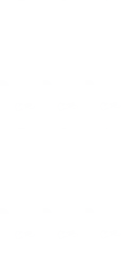

rgbd grid shape: (256, 128, 3)


In [12]:
import mediapy as media

camera_resolution = (128, 128)
rc = mjw.create_render_context(
 model,
 nworld=n_world,
 cam_res=camera_resolution,
 render_rgb=True,
 render_depth=True,
)

# Populate data fields for the current state
mjw.forward(mjw_model, mjw_data)
mjw.refit_bvh(mjw_model, mjw_data, rc)

# Render the current state
mjw.render(mjw_model, mjw_data, rc)

# rgb_data = wp.zeros((n_world, camera_resolution[1], camera_resolution[0]), dtype=wp.vec3)
# mjw.get_rgb(rc, camera_index=0, rgb_out=rgb_data)
rgb_data = rc.rgb_data.numpy()
print("rgb_data shape:", rgb_data.shape) # n_world x height x width x 2

# Display our rendered worlds in a grid
rgb_grid = rgb_data.reshape(2, 1, camera_resolution[1], camera_resolution[0], 3) # 3
rgb_grid = rgb_grid.transpose(0, 2, 1, 3, 4)
rgb_grid = rgb_grid.reshape(2 * camera_resolution[0], 1 * camera_resolution[1], 3)
media.show_image(rgb_grid)
print("rgbd grid shape:", rgb_grid.shape)


In [ ]:
import os
import subprocess
import mediapy as media
import numpy as np
import warp as wp
import mujoco
import mujoco_warp as mjw

mj_model_with_camera = # here

NWORLD = 16
CAM_RES = (128, 128)
model = mjw.put_model(mj_model_with_camera)
data = mjw.make_data(mj_model_with_camera, nworld=NWORLD)
rc = mjw.create_render_context(
 mj_model_with_camera,
 nworld=NWORLD,
 cam_res=CAM_RES,
 render_rgb=True,
 render_depth=True,
)

# Randomize the qpos of each world
qpos = data.qpos.numpy()
qpos[:, 0] = np.random.uniform(0, 2 * np.pi, size=NWORLD)
data.qpos = wp.array(qpos, dtype=wp.float32)

# Populate data fields for the current state
mjw.forward(model, data)

# Refit BVH updates the internal BVH using the current state. It is necessary to
# call this after the state has been updates and before rendering.
mjw.refit_bvh(model, data, rc)

# Render the current state
mjw.render(model, data, rc)

rgb_data = wp.zeros((NWORLD, CAM_RES[1], CAM_RES[0]), dtype=wp.vec3)
mjw.get_rgb(rc, camera_index=0, rgb_out=rgb_data)

# Display our rendered worlds in a grid
rgb_grid = rgb_data.numpy().reshape(4, 4, CAM_RES[1], CAM_RES[0], 3)
rgb_grid = rgb_grid.transpose(0, 2, 1, 3, 4)
rgb_grid = rgb_grid.reshape(4 * CAM_RES[0], 4 * CAM_RES[1], 3)
media.show_image(rgb_grid)

# Extract depth data, which is scaled and clamped to [0, 1]
depth_data = wp.zeros((NWORLD, CAM_RES[1], CAM_RES[0]), dtype=float)
mjw.get_depth(rc, camera_index=0, depth_scale=3.5, depth_out=depth_data)

# Display our rendered worlds in a grid
depth_grid = depth_data.numpy().reshape(4, 4, CAM_RES[1], CAM_RES[0])
depth_grid = depth_grid.transpose(0, 2, 1, 3)
depth_grid = depth_grid.reshape(4 * CAM_RES[0], 4 * CAM_RES[1])
media.show_image(depth_grid, cmap='gray', vmin=0, vmax=1)